<a href="https://colab.research.google.com/github/AntimaMalik/Antima/blob/main/presentations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten


In [ ]:
# =========================
# 2. LOAD DATASET
# =========================
from google.colab import files
uploaded = files.upload()


Saving rt_iot2022_regression_ready_50_features (1).csv to rt_iot2022_regression_ready_50_features (1).csv


In [ ]:
df = pd.read_csv('rt_iot2022_regression_ready_50_features (1).csv')

In [ ]:
# Assume last column is target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [ ]:
# =========================
# 3. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# =========================
# 4. SCALING
# =========================
print(X_train.dtypes)

# Convert categorical columns to numeric
X = pd.get_dummies(X)

# Now split again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


id.orig_p                  int64
id.resp_p                  int64
proto                     object
service                   object
fwd_pkts_tot               int64
bwd_pkts_tot               int64
fwd_data_pkts_tot          int64
bwd_data_pkts_tot          int64
fwd_pkts_per_sec         float64
bwd_pkts_per_sec         float64
flow_pkts_per_sec        float64
down_up_ratio            float64
fwd_header_size_tot        int64
fwd_header_size_min        int64
fwd_header_size_max        int64
bwd_header_size_tot        int64
bwd_header_size_min        int64
bwd_header_size_max        int64
flow_FIN_flag_count        int64
flow_SYN_flag_count        int64
flow_RST_flag_count        int64
fwd_PSH_flag_count         int64
bwd_PSH_flag_count         int64
flow_ACK_flag_count        int64
fwd_URG_flag_count         int64
bwd_URG_flag_count         int64
flow_CWR_flag_count        int64
flow_ECE_flag_count        int64
fwd_pkts_payload.min       int64
fwd_pkts_payload.max       int64
fwd_pkts_p

In [ ]:
# =========================
# 5. EVALUATION FUNCTION
# =========================
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

results = []

Decision Tree Results:
{'Model': 'Decision Tree', 'MSE': 0.46999574584651443, 'RMSE': np.float64(0.6855623573727735), 'MAE': 0.01616808970922678, 'R2': 0.9984771613851214}


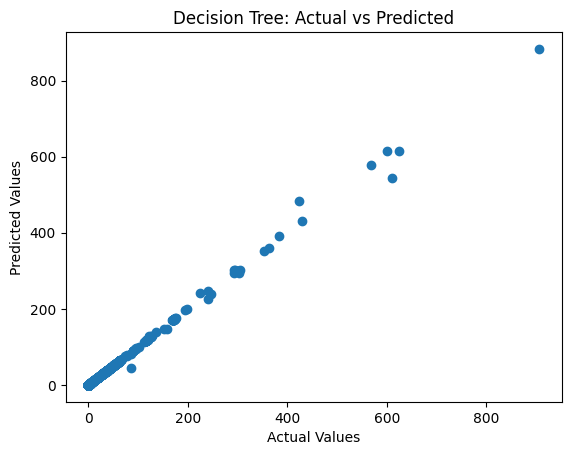

In [ ]:
# =========================
# 6. DECISION TREE REGRESSOR
# =========================
from sklearn.tree import DecisionTreeRegressor

dt_regressor = DecisionTreeRegressor(random_state=42)

dt_regressor.fit(X_train, y_train)

# =========================
# 9. PREDICTION
# =========================
y_pred_dt = dt_regressor.predict(X_test)

# =========================
# 10. EVALUATION
# =========================
dt_results = evaluate_model("Decision Tree", y_test, y_pred_dt)
results.append(dt_results)

print("Decision Tree Results:")
print(dt_results)

# =========================
# 11. VISUALIZATION
# =========================

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

KNN Results:
{'Model': 'KNN', 'MSE': 52.91103683437156, 'RMSE': np.float64(7.2739973078336755), 'MAE': 0.28639130748050684, 'R2': 0.8285623417728689}


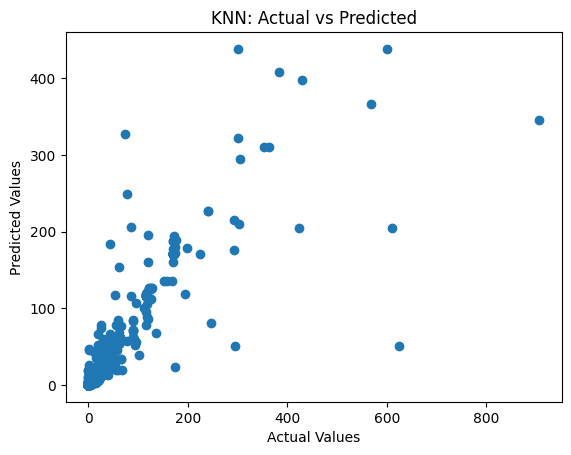

In [ ]:
# =========================
# 8. K-NEAREST NEIGHBORS (KNN)
# =========================

knn = KNeighborsRegressor(n_neighbors=5) # You can experiment with different numbers of neighbors

knn.fit(X_train, y_train)

# =========================
# 9. PREDICTION
# =========================
y_pred_knn = knn.predict(X_test)

# =========================
# 10. EVALUATION
# =========================
knn_results = evaluate_model("KNN", y_test, y_pred_knn)
results.append(knn_results)

print("KNN Results:")
print(knn_results)

# =========================
# 11. VISUALIZATION
# =========================

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("KNN: Actual vs Predicted")
plt.show()

Random Forest Results:
{'Model': 'Random Forest', 'MSE': 2.139823292194605, 'RMSE': np.float64(1.4628134851014347), 'MAE': 0.02903352936087219, 'R2': 0.993066733971174}


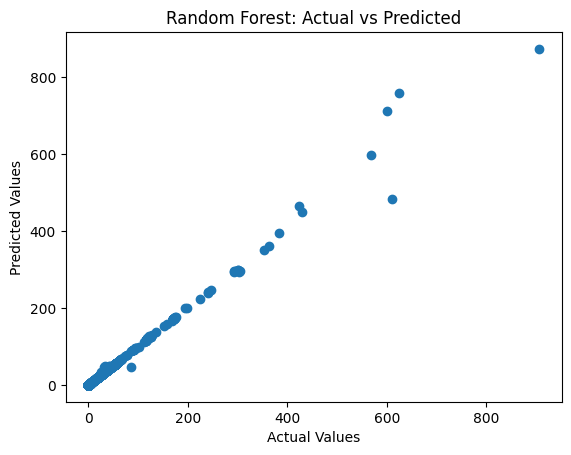

In [ ]:
# =========================
# 7. RANDOM FOREST REGRESSOR
# =========================

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

rf_regressor.fit(X_train, y_train)

# =========================
# 9. PREDICTION
# =========================
y_pred_rf = rf_regressor.predict(X_test)

# =========================
# 10. EVALUATION
# =========================
rf_results = evaluate_model("Random Forest", y_test, y_pred_rf)
results.append(rf_results)

print("Random Forest Results:")
print(rf_results)

# =========================
# 11. VISUALIZATION
# =========================

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

### Convolutional Neural Network (CNN)

We'll implement a simple 1D CNN for this regression task. First, we need to reshape the input data `X_train` and `X_test` to be suitable for a 1D CNN layer, which typically expects input in the format `(samples, timesteps, features)`.

In [ ]:
# Reshape data for CNN (add a timestep dimension)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Get input shape for the CNN layer
input_shape = (X_train_cnn.shape[1], 1)

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

X_train_cnn shape: (98493, 61, 1)
X_test_cnn shape: (24624, 61, 1)


Now, let's define the 1D CNN model. We'll use a `Conv1D` layer followed by `Flatten` and `Dense` layers for regression output.

In [ ]:
# =========================
# 7. CONVOLUTIONAL NEURAL NETWORK (CNN)
# =========================

# Define the CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
cnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, verbose=0, validation_split=0.2)

print("CNN training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN training complete.


770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
CNN Results:
{'Model': 'CNN', 'MSE': 1047.9209324772762, 'RMSE': np.float64(32.371606887475885), 'MAE': 1.750180594442991, 'R2': -2.3953806506091992}


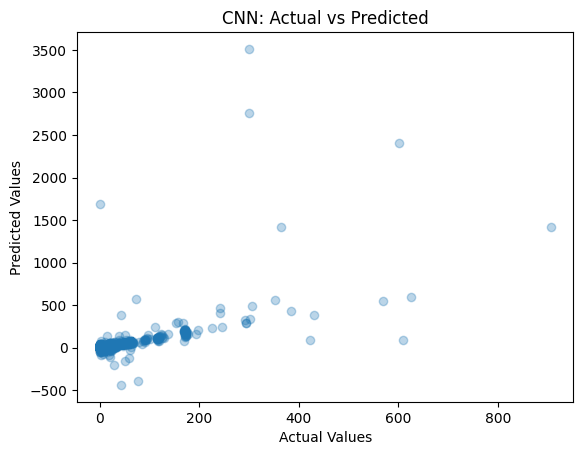

In [ ]:
# =========================
# 9. PREDICTION
# =========================
y_pred_cnn = cnn_model.predict(X_test_cnn).flatten()

# =========================
# 10. EVALUATION
# =========================
cnn_results = evaluate_model("CNN", y_test, y_pred_cnn)
results.append(cnn_results)

print("CNN Results:")
print(cnn_results)

# =========================
# 11. VISUALIZATION
# =========================

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred_cnn, alpha=0.3)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("CNN: Actual vs Predicted")
plt.show()

In [ ]:
print("Evaluation Metrics (MSE, RMSE, MAE, R2):")
for res in results:
    print(f"Model: {res['Model']}, MSE: {res['MSE']:.4f}, RMSE: {res['RMSE']:.4f}, MAE: {res['MAE']:.4f}, R2: {res['R2']:.4f}")

Evaluation Metrics (MSE, RMSE, MAE, R2):
Model: Decision Tree, MSE: 0.4700, RMSE: 0.6856, MAE: 0.0162, R2: 0.9985
Model: KNN, MSE: 52.9110, RMSE: 7.2740, MAE: 0.2864, R2: 0.8286
Model: Random Forest, MSE: 2.1398, RMSE: 1.4628, MAE: 0.0290, R2: 0.9931
Model: CNN, MSE: 1047.9209, RMSE: 32.3716, MAE: 1.7502, R2: -2.3954


,Model,MSE,RMSE,MAE,R2
0,Decision Tree,0.469996,0.685562,0.016168,0.998477
1,KNN,52.911037,7.273997,0.286391,0.828562
2,Random Forest,2.139823,1.462813,0.029034,0.993067
3,CNN,1047.920932,32.371607,1.750181,-2.395381


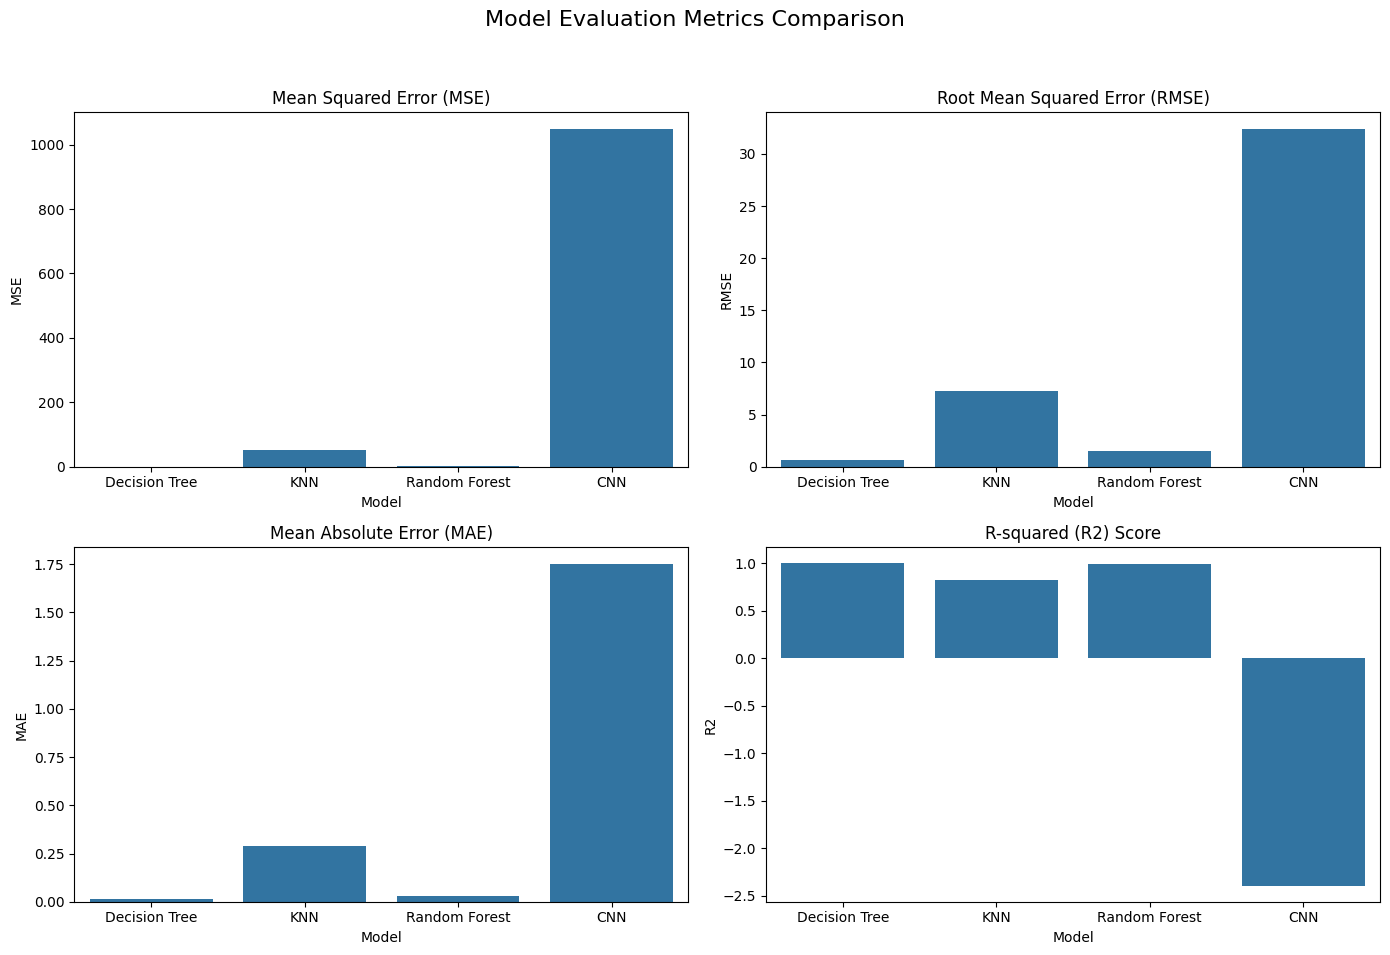

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results_df = pd.DataFrame(results)
display(results_df)

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Evaluation Metrics Comparison', fontsize=16)

# Plot MSE
sns.barplot(ax=axes[0, 0], x='Model', y='MSE', data=results_df)
axes[0, 0].set_title('Mean Squared Error (MSE)')

# Plot RMSE
sns.barplot(ax=axes[0, 1], x='Model', y='RMSE', data=results_df)
axes[0, 1].set_title('Root Mean Squared Error (RMSE)')

# Plot MAE
sns.barplot(ax=axes[1, 0], x='Model', y='MAE', data=results_df)
axes[1, 0].set_title('Mean Absolute Error (MAE)')

# Plot R2 Score
sns.barplot(ax=axes[1, 1], x='Model', y='R2', data=results_df)
axes[1, 1].set_title('R-squared (R2) Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()